In [57]:
import numpy as np
import cv2
from typing import List, Tuple, Any, Dict
import os
import glob
import pickle
from matplotlib import pyplot as plt
from calibration import *
import json

In [58]:
squareLength = 0.0200 # m
markerLength = 0.0150 # m
squaresX = 11
squaresY = 8

In [59]:
def load_images(set: str, side: str) -> List[Tuple[str, str]]:
    return glob.glob(os.path.join(set, f"{side}-*.png"))

def load_image_pairs(set: str) -> List[Tuple[str, str]]:
    n_files = int(len(glob.glob(os.path.join(set, r"*.png"))) / 2)
    return [(os.path.join(set, f"left-{i}.png"), os.path.join(set, f"right-{i}.png")) for i in range(n_files)]

def plot_residuals(model: PinholeCalibrator):
    res = model.residuals
    counts, bins = np.histogram(res, bins=100)

    errs = model.residual_vecs
    x_err = [e[0, 0] for e in errs]
    y_err = [e[0, 1] for e in errs]
    s = np.std(res)
    m = np.mean(res)
    colors = [("blue" if abs(res[i]-m) < (3*s) else "red") for i in range(len(res))]

    fig = plt.figure(figsize=[15, 5])
    ax = fig.subplots(1, 3)
    ax[0].stairs(counts, bins)
    ax[0].set_title("Reprojection Error Histogram")
    ax[0].set_xlabel("Reprojection Error Magnitude [Px]")
    ax[0].set_ylabel("Calibration Point Count")
    ax[1].scatter(x_err, y_err, c=colors)
    ax[1].set_title("Reprojection Error Vectors")
    ax[1].set_xlabel("X Error [Px]")
    ax[1].set_ylabel("Y Error [Px]")
    ax[2].imshow(model.coverage)
    ax[2].set_title("Marker Detection Locations")


def plot_stereo_residuals(model: StereoCalibrator):
    res_l = [r[0] for r in model.residuals]
    res_r = [r[1] for r in model.residuals]

    counts_l, bins_l = np.histogram(res_l, bins=100)
    counts_r, bins_r = np.histogram(res_r, bins=100)

    errs_l = [e[0] for e in model.residual_vecs]
    x_l_err = [e[0, 0] for e in errs_l]
    y_l_err = [e[0, 1] for e in errs_l]
    sl = np.std(res_l)
    ml = np.mean(res_l)
    colors_l = [("blue" if abs(res_l[i]-ml) < (3*sl) else "red") for i in range(len(res_l))]

    errs_r = [e[1] for e in model.residual_vecs]
    x_r_err = [e[0, 0] for e in errs_r]
    y_r_err = [e[0, 1] for e in errs_r]
    sr = np.std(res_r)
    mr = np.mean(res_r)
    colors_r = [("blue" if abs(res_r[i]-mr) < (3*sr) else "red") for i in range(len(res_r))]
    
    fig = plt.figure(figsize=[10, 10])
    ax = fig.subplots(2, 2)
    ax[0, 0].stairs(counts_l, bins_l)
    ax[0, 0].set_title("Left reprojection Error Histogram")
    ax[0, 0].set_xlabel("Reprojection Error Magnitude [Px]")
    ax[0, 0].set_ylabel("Calibration Point Count")
    ax[0, 1].stairs(counts_r, bins_r)
    ax[0, 1].set_title("Right reprojection Error Histogram")
    ax[0, 1].set_xlabel("Reprojection Error Magnitude [Px]")
    ax[0, 1].set_ylabel("Calibration Point Count")
    ax[1, 0].scatter(x_l_err, y_l_err, c=colors_l)
    ax[1, 0].set_title("Left reprojection Error Vectors")
    ax[1, 0].set_xlabel("X Error [Px]")
    ax[1, 0].set_ylabel("Y Error [Px]")
    ax[1, 1].scatter(x_r_err, y_r_err, c=colors_r)
    ax[1, 1].set_title("Right reprojection Error Vectors")
    ax[1, 1].set_xlabel("X Error [Px]")
    ax[1, 1].set_ylabel("Y Error [Px]")

def remove_outliers_iter(model: PinholeCalibrator | StereoCalibrator, a: float = 3.0, max_iter: int = 5, tol: float = 1e-3):
    s_prev = np.std(model.residuals)
    for i in range(max_iter):
        model.remove_outliers(a)
        model.recalculate()
        s = np.std(model.residuals)
        if abs(s - s_prev) < tol:
            break
        s_prev = s
        

Individual Camera Calibration
=============================

The calibration for each cameras intrinsics follows the following process:

1. Load all images and detect locations of charuco markers
2. Calculate camera calibration
3. Calculate reprojection error for each individual marker
4. Remove all markers more than 3 standard deviations away from the mean error
5. Repeat from step 2 until reprojection errors don't change, max of 5 iterations 

In [60]:
left = PinholeCalibrator(
    (800, 600),
    (squaresX, squaresY),
    squareLength, markerLength,
    [*load_images("set_1", "left"), *load_images("set_2", "left"), *load_images("set_3", "left")]
)

print(f"{left.count} calibration images processed, {left.count_valid} used, reprojection error {left.rms}")

255 calibration images processed, 44 used, reprojection error 0.4973612043963301


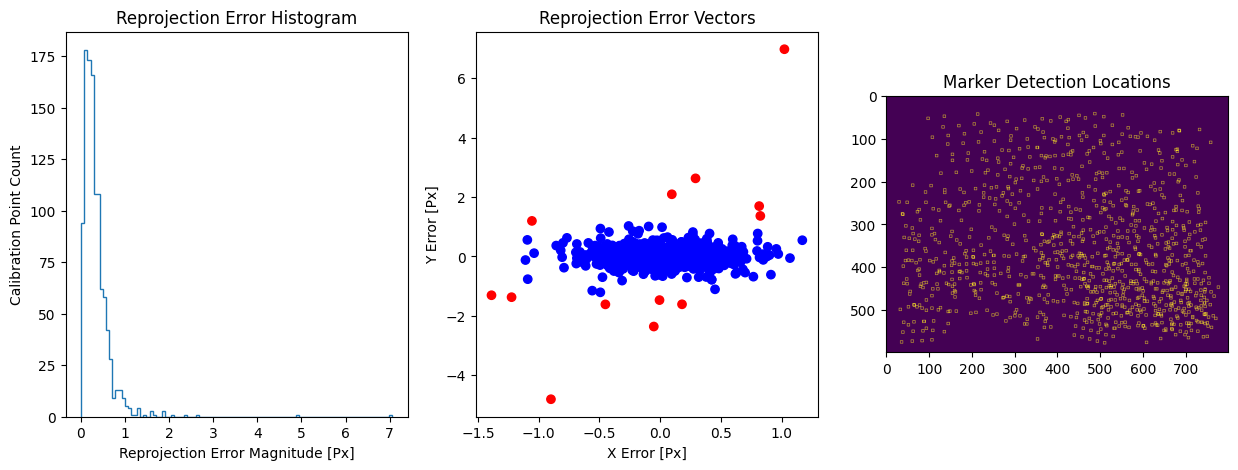

In [61]:
plot_residuals(left)

In [62]:
remove_outliers_iter(left)
print(f"Outliers removed, {left.count_valid} used, new reprojection error {left.rms}")

Outliers removed, 44 used, new reprojection error 0.2957152768769914


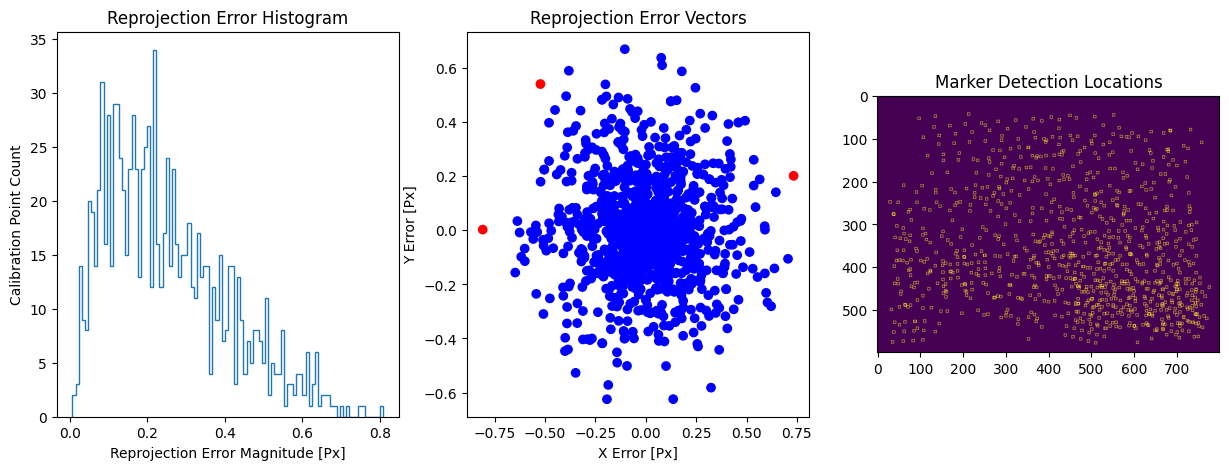

In [63]:
plot_residuals(left)

In [64]:
right = PinholeCalibrator(
    (800, 600),
    (squaresX, squaresY),
    squareLength, markerLength,
    [*load_images("set_1", "right"), *load_images("set_2", "right"), *load_images("set_3", "right")]
)

print(f"{left.count} calibration images processed, {left.count_valid} used, reprojection error {left.rms}")

255 calibration images processed, 44 used, reprojection error 0.2957152768769914


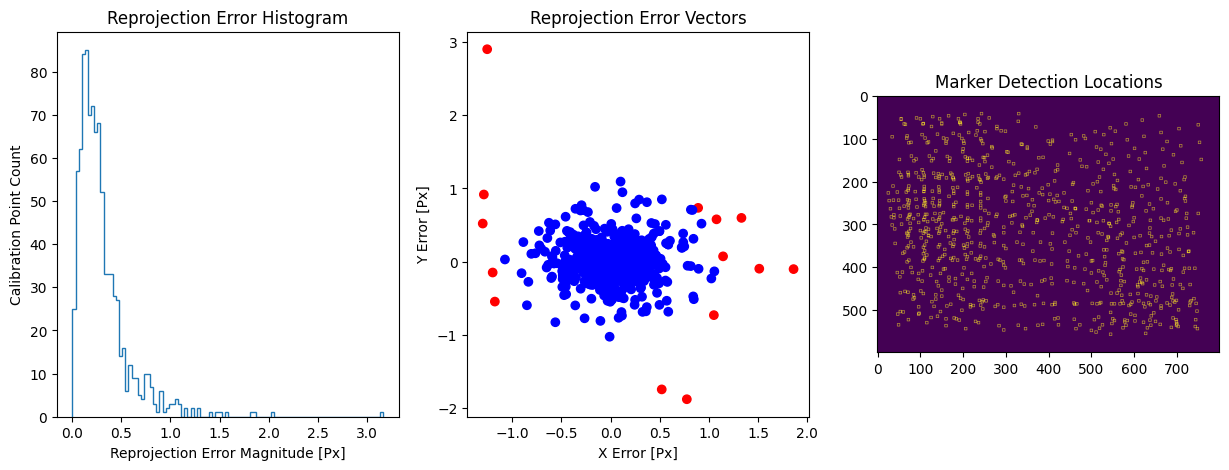

In [65]:
plot_residuals(right)

In [66]:
remove_outliers_iter(right)
print(f"Outliers removed, {right.count_valid} used, new reprojection error {right.rms}")

Outliers removed, 38 used, new reprojection error 0.26988805984697806


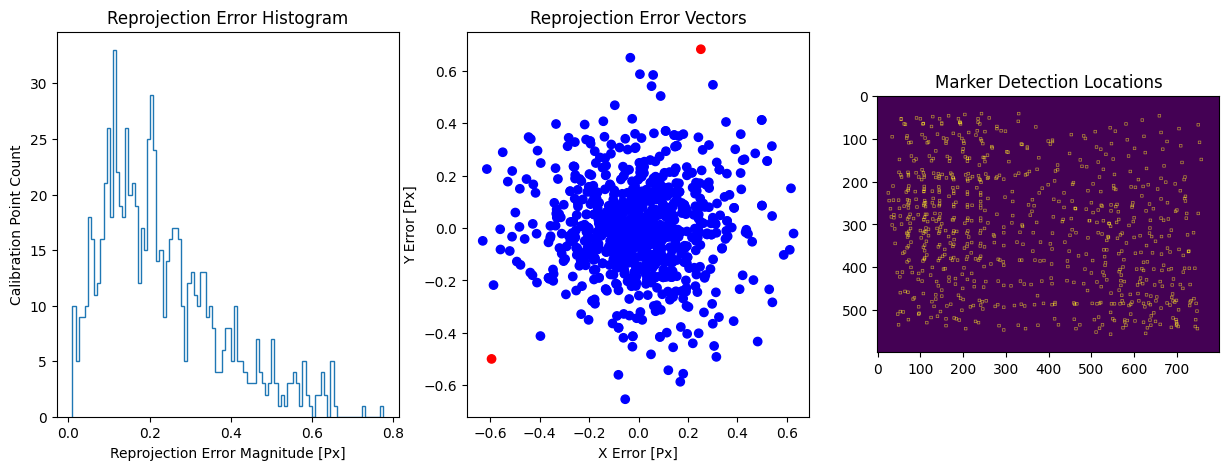

In [67]:
plot_residuals(right)

Stereo Camera Calibration
=========================

Calibrating stereo extrinsics follows a similar procedure as each individual camera:

1. Load all images and detect locations of charuco markers
2. Isolate only the markers that are detected in both images
3. Calculate stereo calibration
4. Calculate reprojection error for each individual marker in each camera
    * In the right camera, reprojection uses the estimated stereo translation and rotation
5. Remove all markers more than 3 standard deviations away from the mean error for their camera
    * Markers that are outliers in one cameras set are removed from both, since stereo matching needs identical points in each camera..
6. Repeat from step 3 until reprojection errors don't change, max of 5 iterations 

In [68]:
stereo = StereoCalibrator(left, right, 
                          [*load_image_pairs("set_1"), *load_image_pairs("set_2"), *load_image_pairs("set_3")]
                        )
print(f"{stereo.count} calibration pairs processed, {stereo.count_valid} used, reprojection error {stereo.rms}")

255 calibration pairs processed, 15 used, reprojection error 3222.735439435573


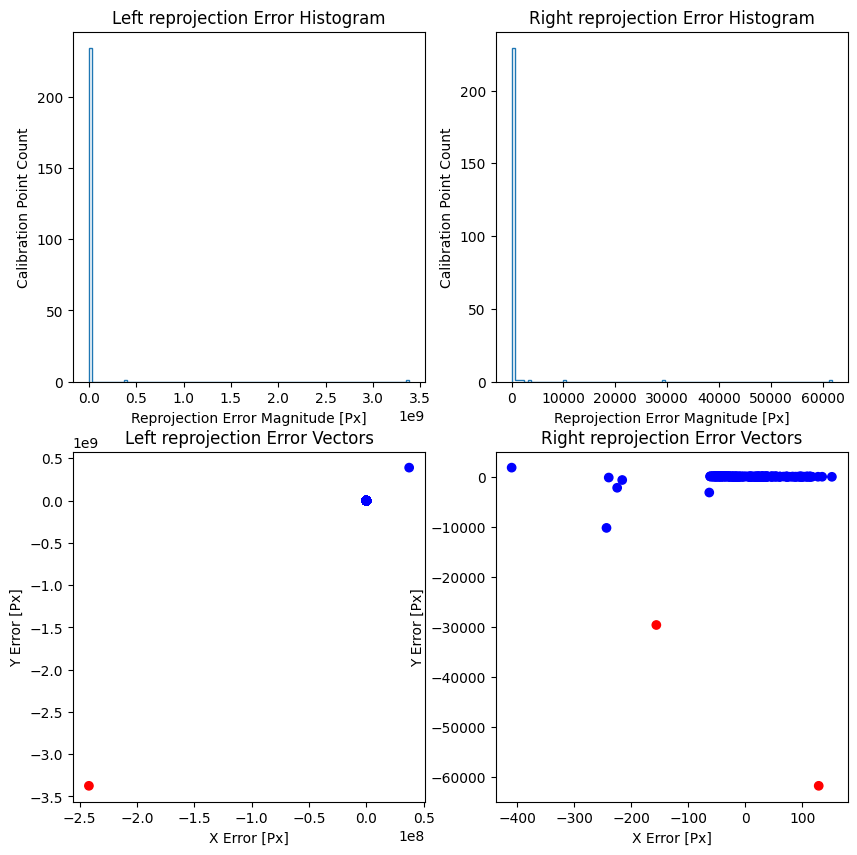

In [69]:
plot_stereo_residuals(stereo)

In [70]:
remove_outliers_iter(stereo)
print(f"Outliers removed, {stereo.count_valid} used, new reprojection error {stereo.rms}")

Outliers removed, 14 used, new reprojection error 2.945088219654362


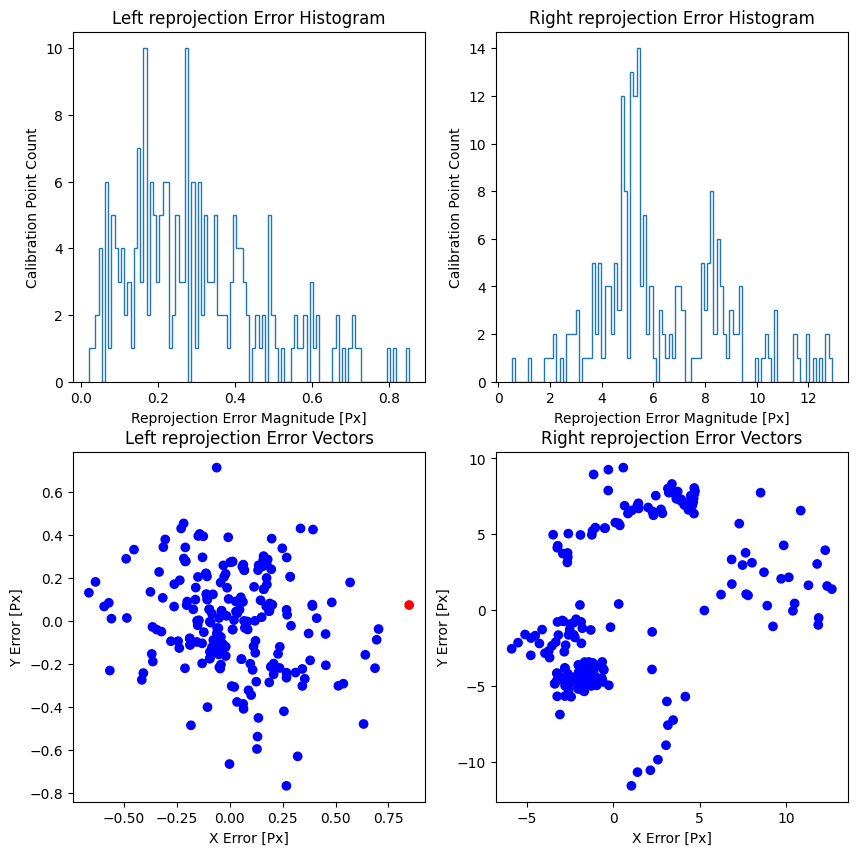

In [71]:
plot_stereo_residuals(stereo)

Save Calibration Results
========================

In [72]:
print(f"Left Intrinsic: {left.intrinsic}")
print(f"Left Distortion: {left.distortion}")
print(f"Right Intrinsic: {right.intrinsic}")
print(f"Right Distortion: {right.distortion}")
print(f"Stereo translation: {stereo.T}")
print(f"Stereo rotation: {stereo.R}")

Left Intrinsic: [[634.07617327   0.         393.71763714]
 [  0.         635.42742207 322.98440982]
 [  0.           0.           1.        ]]
Left Distortion: [[ 2.01486280e-01 -5.41851287e-01  4.13104753e-03  5.06318544e-04
   4.22353921e-01]]
Right Intrinsic: [[634.06673742   0.         386.33974132]
 [  0.         635.52297475 310.59702299]
 [  0.           0.           1.        ]]
Right Distortion: [[ 0.21144909 -0.55513567  0.00297351 -0.00354429  0.4336787 ]]
Stereo translation: [[-0.05795877]
 [-0.00100914]
 [ 0.00390513]]
Stereo rotation: [[ 0.99939364  0.0184213  -0.02954671]
 [-0.02004035  0.99825921 -0.05547013]
 [ 0.02847345  0.05602862  0.99802307]]


In [73]:
R1, R2, Pn1, Pn2, Q, ROI1, ROI2 = cv2.stereoRectify(
            left.intrinsic, left.distortion, 
            right.intrinsic, right.distortion, left.image_size, stereo.R, stereo.T,
            alpha=0, flags=cv2.CALIB_ZERO_DISPARITY
            )

In [74]:
print(f"Stereo projection: {Q}")

Stereo projection: [[   1.            0.            0.         -462.33940506]
 [   0.            1.            0.         -318.02495956]
 [   0.            0.            0.          801.06510213]
 [   0.            0.           17.21201775   -0.        ]]


Cross Validation
================

Cross validation attempts to ensure that the camera models are not being overfit to noise in their datasets.

A camera model is fit to 70% of the images in the given set, then reprojection error is calculated for points detected
in the remaining 30% of images. 

For both cameras the reprojection error from fitting the model is similar to the reprojection error in the test images.
If the error in the test images were much higher it would suggest overfitting, but that does not appear to be the case.

In [75]:
cv = PinholeCrossValidator(
    (800, 600),
    (squaresX, squaresY),
    squareLength, markerLength,
    [*load_images("set_1", "left"), *load_images("set_2", "left"), *load_images("set_3", "left")]#, *load_images("set_4", "left")]
)

print(f"Left model fit error {cv.model.rms}, cross-validation error {cv.rms} with {cv.count} test images")

Left model fit error 0.5321188511622157, cross-validation error 0.3535030782222748 with 77 test images


In [76]:
cv = PinholeCrossValidator(
    (800, 600),
    (squaresX, squaresY),
    squareLength, markerLength,
    [*load_images("set_1", "right"), *load_images("set_2", "right"), *load_images("set_3", "right")]#, *load_images("set_4", "right")]
)

print(f"Right model fit error {cv.model.rms}, cross-validation error {cv.rms} with {cv.count} test images")

Right model fit error 0.3547053505063029, cross-validation error 0.4224059283733368 with 77 test images


Save Parameters
===============

Save in pickle format used for testing in Python notebooks, and in JSON format used by C++ program.

In [77]:
with open("parameters.pickle", "wb") as file:
    pickle.dump(
        (
            left.intrinsic, left.distortion, 
            right.intrinsic, right.distortion, 
            stereo.T, stereo.R, Q, ROI1, ROI2, R1, R2, Pn1, Pn2
        ), file)

In [78]:
with open("left.json", "w") as file:
    json.dump({
        "intrinsic": [
            left.intrinsic[0,0],
            left.intrinsic[0,1],
            left.intrinsic[0,2],
            left.intrinsic[1,0],
            left.intrinsic[1,1],
            left.intrinsic[1,2],
            left.intrinsic[2,0],
            left.intrinsic[2,1],
            left.intrinsic[2,2]
        ],
        "distortion": [
            left.distortion[0,0],
            left.distortion[0,1],
            left.distortion[0,2],
            left.distortion[0,3],
            left.distortion[0,4]
        ]
    }, file)

In [79]:
with open("right.json", "w") as file:
    json.dump({
        "intrinsic": [
            right.intrinsic[0,0],
            right.intrinsic[0,1],
            right.intrinsic[0,2],
            right.intrinsic[1,0],
            right.intrinsic[1,1],
            right.intrinsic[1,2],
            right.intrinsic[2,0],
            right.intrinsic[2,1],
            right.intrinsic[2,2]
        ],
        "distortion": [
            right.distortion[0,0],
            right.distortion[0,1],
            right.distortion[0,2],
            right.distortion[0,3],
            right.distortion[0,4]
        ]
    }, file)

In [80]:
with open("stereo_calibration.json", "w") as file:
    json.dump({
        "rotation": [
            stereo.R[0,0],
            stereo.R[0,1],
            stereo.R[0,2],
            stereo.R[1,0],
            stereo.R[1,1],
            stereo.R[1,2],
            stereo.R[2,0],
            stereo.R[2,1],
            stereo.R[2,2]
        ],
        "translation": [
            stereo.T[0,0],
            stereo.T[1,0],
            stereo.T[2,0]
        ]
    }, file)